In [2]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

In [3]:
widthD = 60

X, Y = widthD, 60
lattice = Lattice(X, Y)

t = 1
T = 0.01

muD = 0.50 * t
mu = np.ones(lattice.X) * muD

U = None
V_prime = None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)

In [4]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.5, 0.5, -0.5, -0.5])

In [5]:
bdg_sc(H, atol=1e-6, rtol=0.001, maxiter=1000, temperature=T,verbose=True)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.06768280462673187
Relative error: 67682804626.73187
Average old: 0j
Average: (0.0054942731901834645+0j)
F_xplus:
Absolute error: 1.3667147075951946
Relative error: 2.7334294151849226
Average old: (0.5+0j)
Average: (0.32241873743026567+0j)
F_xmin:
Absolute error: 1.3667147075951949
Relative error: 2.733429415184923
Average old: (0.5+0j)
Average: (0.3224187374302656+0j)
F_yplus:
Absolute error: 1.3614218868270835
Relative error: 2.722843773659612
Average old: (-0.5+0j)
Average: (-0.32431817427957793+1.457313785946533e-17j)
F_ymin:
Absolute error: 1.3614218868270835
Relative error: 2.722843773659612
Average old: (-0.5+0j)
Average: (-0.32431817427957793-1.457313785946533e-17j)
Fuu_xplus:
Absolute error: 2.291406578150509e-16
Relative error: 0.00022914065781505096
Average old: 0j
Average: (1.4245068041142666e-17+0j)
Fuu_xmin:
Absolute error: 2.2576450152260945e-16
Relative error: 0.00022576450152260945
Average old: 0j
Average: (1.299668282434269e-17+0j)
Fuu_yplus:
Abso

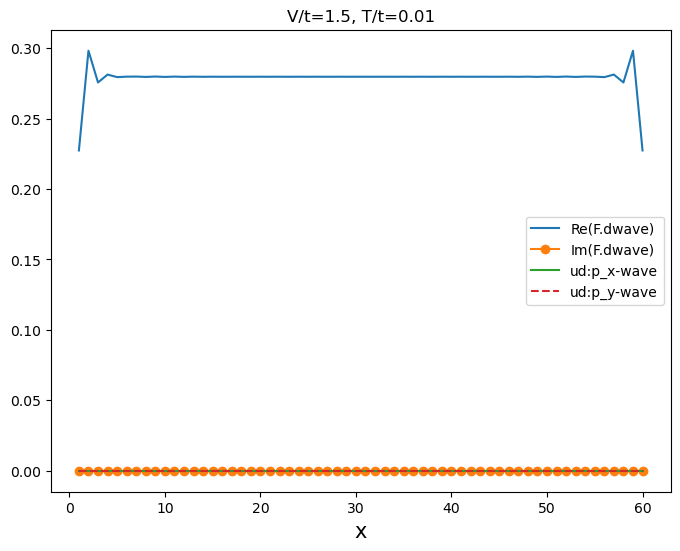

In [6]:
x = np.arange(1, widthD + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"V/t={V0}, T/t={T}")
axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
axs.plot(x, np.imag(F.dwave), '-o', label="Im(F.dwave)")
axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.axhline(0.33, linestyle='--', color="red")
axs.legend()
plt.show()

In [7]:
print(F.dwave[X//2])

(0.2796572998682462+0j)


In [8]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.61 + 1e-12, 0.01)
])  # 109 temps total
print(len(temps))

70


In [9]:
width = 30
X, Y = width, 100
lattice = Lattice(X, Y)

t = 1
T = 0.01

muP = 1.8 * t
mu = np.ones(lattice.X) * muP

U = None
V_prime = None

V0 = 2 * t
V = V0 * np.ones(lattice.X)
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1, -0.1, 0.1j, -0.1j])


In [10]:
bdg_sc(H, atol=1e-3, rtol=0.1, maxiter=1000, temperature=T,verbose=True)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 6.418556263495273e-16
Relative error: 0.0006418556263495274
Average old: 0j
Average: (6.739936794630935e-17+0j)
F_xplus:
Absolute error: 0.2582903709241517
Relative error: 2.5829037092156875
Average old: (0.09999999999999999+0j)
Average: (0.14659218012809372+0j)
F_xmin:
Absolute error: 0.258290370924152
Relative error: 2.5829037092673492
Average old: (-0.09999999999999999+0j)
Average: (-0.14659218012809375+0j)
F_yplus:
Absolute error: 0.3033215344247777
Relative error: 3.033215344247777
Average old: 0.1j
Average: (2.035118766386296e-17+0.15484391639307754j)
F_ymin:
Absolute error: 0.3033215344247777
Relative error: 3.033215344247777
Average old: -0.1j
Average: (2.035118766386296e-17-0.15484391639307754j)
Fuu_xplus:
Absolute error: 5.1618505078621094e-17
Relative error: 5.16185050786211e-05
Average old: 0j
Average: (-6.173949591926407e-19+0j)
Fuu_xmin:
Absolute error: 5.642846355836103e-17
Relative error: 5.642846355836103e-05
Average old: 0j
Average: (-3.84327996396

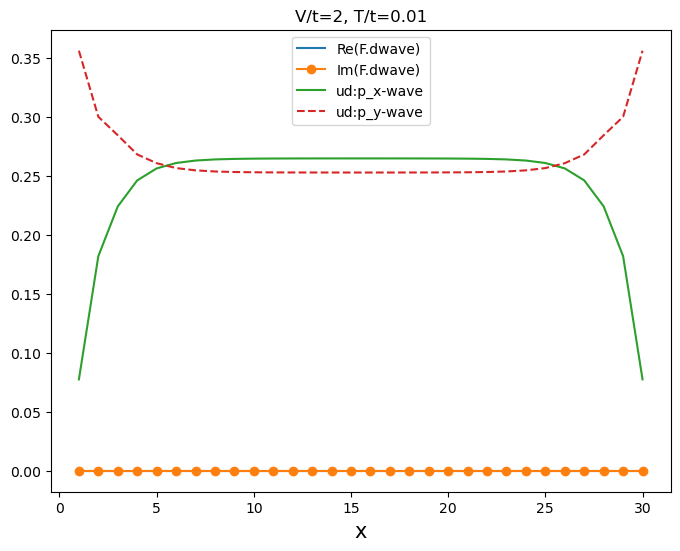

In [11]:
x = np.arange(1, width + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"V/t={V0}, T/t={T}")
axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
axs.plot(x, np.imag(F.dwave), '-o', label="Im(F.dwave)")
axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.axhline(0.33, linestyle='--', color="red")
axs.legend()
plt.show()

In [12]:
width = 60
X, Y = width, 60
lattice = Lattice(X, Y)

t = 1
T = 0.01

muP = 1.8 * t
mu = np.ones(lattice.X) * muP

U = None
V_prime = None

V0 = 2 * t
V = V0 * np.ones(lattice.X)
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1, -0.1, 0.1j, -0.1j])


In [13]:
bdg_sc(H, atol=1e-3, rtol=0.1, maxiter=1000, temperature=T,verbose=True)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 1.1457058431878386e-15
Relative error: 0.0011457058431878385
Average old: 0j
Average: (-5.0786924491561016e-18+0j)
F_xplus:
Absolute error: 0.3931383509644526
Relative error: 3.931383509605211
Average old: (0.09999999999999999+0j)
Average: (0.1504564722153526+0j)
F_xmin:
Absolute error: 0.39313835096445215
Relative error: 3.931383509683835
Average old: (-0.09999999999999999+0j)
Average: (-0.15045647221535255+0j)
F_yplus:
Absolute error: 0.41324026199859126
Relative error: 4.132402619985913
Average old: 0.10000000000000002j
Average: (3.737534982222945e-17+0.15304152928555753j)
F_ymin:
Absolute error: 0.41324026199859126
Relative error: 4.132402619985913
Average old: -0.10000000000000002j
Average: (3.737534982222945e-17-0.15304152928555753j)
Fuu_xplus:
Absolute error: 2.364887882678576e-16
Relative error: 0.00023648878826785754
Average old: 0j
Average: (-2.5142872724031836e-17+0j)
Fuu_xmin:
Absolute error: 2.9322839094892806e-16
Relative error: 0.00029322839094892805


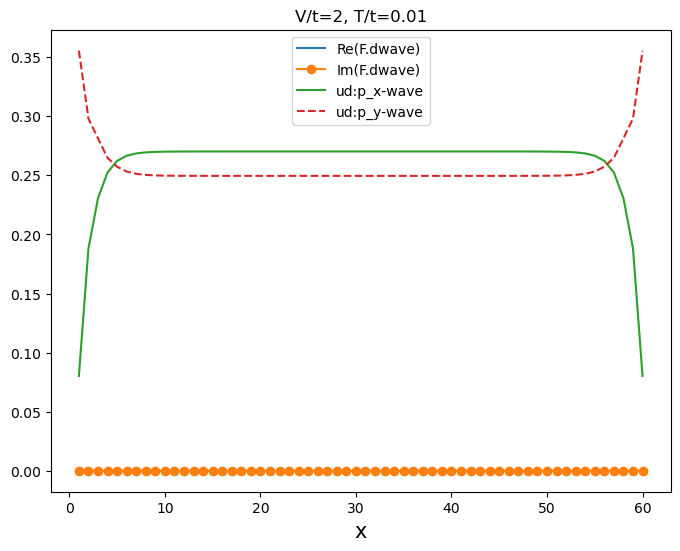

In [14]:
x = np.arange(1, width + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"V/t={V0}, T/t={T}")
axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
axs.plot(x, np.imag(F.dwave), '-o', label="Im(F.dwave)")
axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.axhline(0.33, linestyle='--', color="red")
axs.legend()
plt.show()

In [15]:
print(F.py[X//2])
print(F.px[X//2])


0.24956510115604053j
(0.2702341801986249+0j)
